# Training Fusion Model for Binary Pest Classification

## STEP 1: SETUP & IMPORTS
Setup libraries, constants, and device configuration for binary pest classification.

This notebook uses a fusion model combining: `EfficientNetV2-S + ResNet50`.

In [ ]:
import os
import random
import copy
import time
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
from PIL import Image
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True  # FIX cho loi OSError: image file is truncated

try:
    import seaborn as sns
except ModuleNotFoundError:
    sns = None
    print('Seaborn is not installed; confusion matrix will use Matplotlib fallback.')

try:
    from sklearn.metrics import confusion_matrix, classification_report
except ModuleNotFoundError:
    confusion_matrix = None
    classification_report = None
    print('scikit-learn is not installed; classification report will use NumPy fallback.')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models

# ==================== CONFIG ====================
SEED        = 42
IMG_SIZE    = 288
BATCH_SIZE  = 32
EPOCHS      = 10
LR          = 1e-3
NUM_WORKERS = 0  # Windows/Jupyter is most stable with 0

DATA_DIR = Path('/kaggle/input/datasets/hadesoverflow/dataset-classify-pest')
if not DATA_DIR.exists():
    raise FileNotFoundError(f'Dataset not found at: {DATA_DIR.resolve()}')

SAVE_DIR = Path('outputs_pest_classifier')
SAVE_DIR.mkdir(exist_ok=True)
# ================================================

# Reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PIN_MEMORY = device.type == 'cuda'
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'  GPU: {torch.cuda.get_device_name(0)}')
    print(f'  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print(f'Dataset: {DATA_DIR.resolve()}')
print(f'Output : {SAVE_DIR.resolve()}')

### Exploratory Data Analysis (EDA)

In [6]:
image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
class_names = sorted([p.name for p in DATA_DIR.iterdir() if p.is_dir()])
NUM_CLASSES = len(class_names)

print(f'Classes ({NUM_CLASSES}):', class_names)
print()

count_data = {}
for cls in class_names:
    folder = DATA_DIR / cls
    if folder.exists():
        n = sum(1 for f in folder.iterdir() if f.is_file() and f.suffix.lower() in image_extensions)
        count_data[cls] = n
    else:
        count_data[cls] = 0

print(f"{'Class':<20} {'Total':>7}")
print('-' * 30)
for cls in class_names:
    print(f"{cls:<20} {count_data[cls]:>7}")
print('-' * 30)
print(f"{'TOTAL':<20} {sum(count_data.values()):>7}")

if NUM_CLASSES < 2:
    raise ValueError('Dataset needs at least 2 classes for classification.')

Classes (2): ['non-pest', 'pest']

Class                  Total
------------------------------
non-pest                5000
pest                    5494
------------------------------
TOTAL                  10494


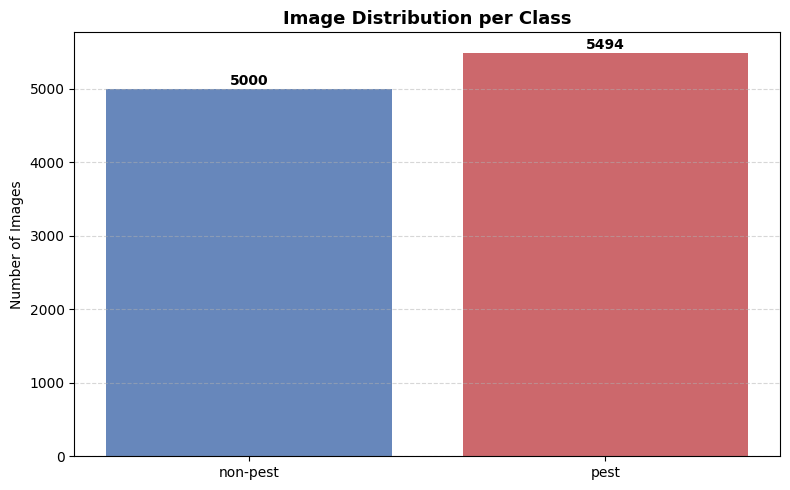

In [7]:
# Visualize number of images distribution
x = np.arange(len(class_names))
counts = [count_data[c] for c in class_names]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(x, counts, color=['#4C72B0', '#C44E52'], alpha=0.85)

for bar, val in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(class_names, fontsize=10)
ax.set_ylabel('Number of Images')
ax.set_title('Image Distribution per Class', fontsize=13, fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

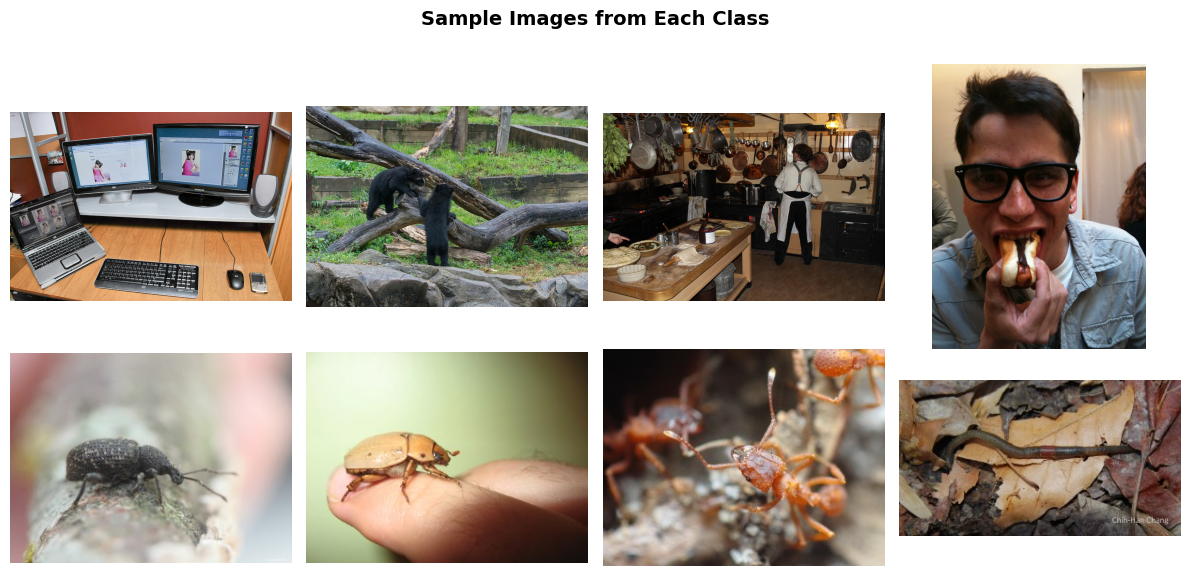

In [8]:
# Display sample images from each class
N_SAMPLES = 4
fig, axes = plt.subplots(NUM_CLASSES, N_SAMPLES, figsize=(N_SAMPLES*3, NUM_CLASSES*3))
fig.suptitle('Sample Images from Each Class', fontsize=14, fontweight='bold', y=1.01)

if NUM_CLASSES == 1:
    axes = axes[None, :]

for row, cls in enumerate(class_names):
    cls_dir = DATA_DIR / cls
    imgs = random.sample(list(cls_dir.glob('*.*')), min(N_SAMPLES, count_data[cls]))
    for col, img_path in enumerate(imgs):
        if img_path.suffix.lower() not in image_extensions: continue
        try:
            img = Image.open(img_path).convert('RGB')
            axes[row, col].imshow(img)
        except Exception:
            pass
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(cls, fontsize=12, rotation=0, labelpad=40, va='center')

plt.tight_layout()
plt.show()

## STEP 2 & 3: TRANSFORMS AND DATA PIPELINE
Define balancing rules, Generator DataLoader, and integrate with Backbone Freezing utilities.

In [9]:
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

# Load entire dataset
full_dataset = datasets.ImageFolder(DATA_DIR)
class_names = full_dataset.classes
NUM_CLASSES = len(class_names)
class_to_idx = full_dataset.class_to_idx
idx_to_class = {idx: cls for cls, idx in class_to_idx.items()}

with open(SAVE_DIR / 'class_to_idx.json', 'w', encoding='utf-8') as f:
    json.dump(class_to_idx, f, ensure_ascii=False, indent=2)

# Random split: 80% train, 10% val, 10% test
total_len = len(full_dataset)
train_len = int(0.8 * total_len)
val_len   = int(0.1 * total_len)
test_len  = total_len - train_len - val_len

train_ds, val_ds, test_ds = random_split(
    full_dataset, [train_len, val_len, test_len],
    generator=torch.Generator().manual_seed(SEED)
)

# Apply specific transforms to splits using wrapper
# We also add a robust try-except to handle corrupted/Unidentified images gracefully.
class DatasetWrapper(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
    def __getitem__(self, index):
        while True:
            try:
                x, y = self.subset[index]
                if self.transform:
                    x = self.transform(x)
                return x, y
            except Exception as e:
                # If image is corrupted (e.g. UnidentifiedImageError), pick a random new index
                index = random.randint(0, len(self.subset) - 1)
    def __len__(self):
        return len(self.subset)

train_dataset = DatasetWrapper(train_ds, transform=train_transform)
val_dataset   = DatasetWrapper(val_ds, transform=val_transform)
test_dataset  = DatasetWrapper(test_ds, transform=val_transform)

# Extract targets for Class weight calculation (only using train split)
train_targets = [full_dataset.targets[i] for i in train_ds.indices]
train_counts = Counter(train_targets)
class_counts = torch.tensor([train_counts.get(i, 0) for i in range(NUM_CLASSES)], dtype=torch.float32)
class_weights = class_counts.sum() / (NUM_CLASSES * class_counts)

print('Class mapping:', class_to_idx)
print('Train class counts :', {class_names[i]: int(class_counts[i].item()) for i in range(NUM_CLASSES)})
print('Class weights:', {class_names[i]: round(class_weights[i].item(), 3) for i in range(NUM_CLASSES)})

# DataLoader
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
)

print(f'Train: {len(train_dataset):,} images | {len(train_loader)} batches')
print(f'Valid: {len(val_dataset):,} images | {len(val_loader)} batches')
print(f'Test:  {len(test_dataset):,} images | {len(test_loader)} batches')

# ===== Freeze Backbone Utility =====
def freeze_batchnorm_layers(module):
    for m in module.modules():
        if isinstance(m, nn.BatchNorm2d):
            m.eval()
            if m.weight is not None:
                m.weight.requires_grad = False
            if m.bias is not None:
                m.bias.requires_grad = False

def set_batchnorm_eval(module):
    for m in module.modules():
        if isinstance(m, nn.BatchNorm2d):
            m.eval()

Class mapping: {'non-pest': 0, 'pest': 1}
Train class counts : {'non-pest': 4000, 'pest': 4395}
Class weights: {'non-pest': 1.049, 'pest': 0.955}
Train: 8,395 images | 263 batches
Valid: 1,049 images | 33 batches
Test:  1,050 images | 33 batches


### Display Sample Batch and Normalization

Batch images shape : torch.Size([32, 3, 288, 288])
Batch labels shape : torch.Size([32])
Pixel value range  : [-2.118, 2.640]


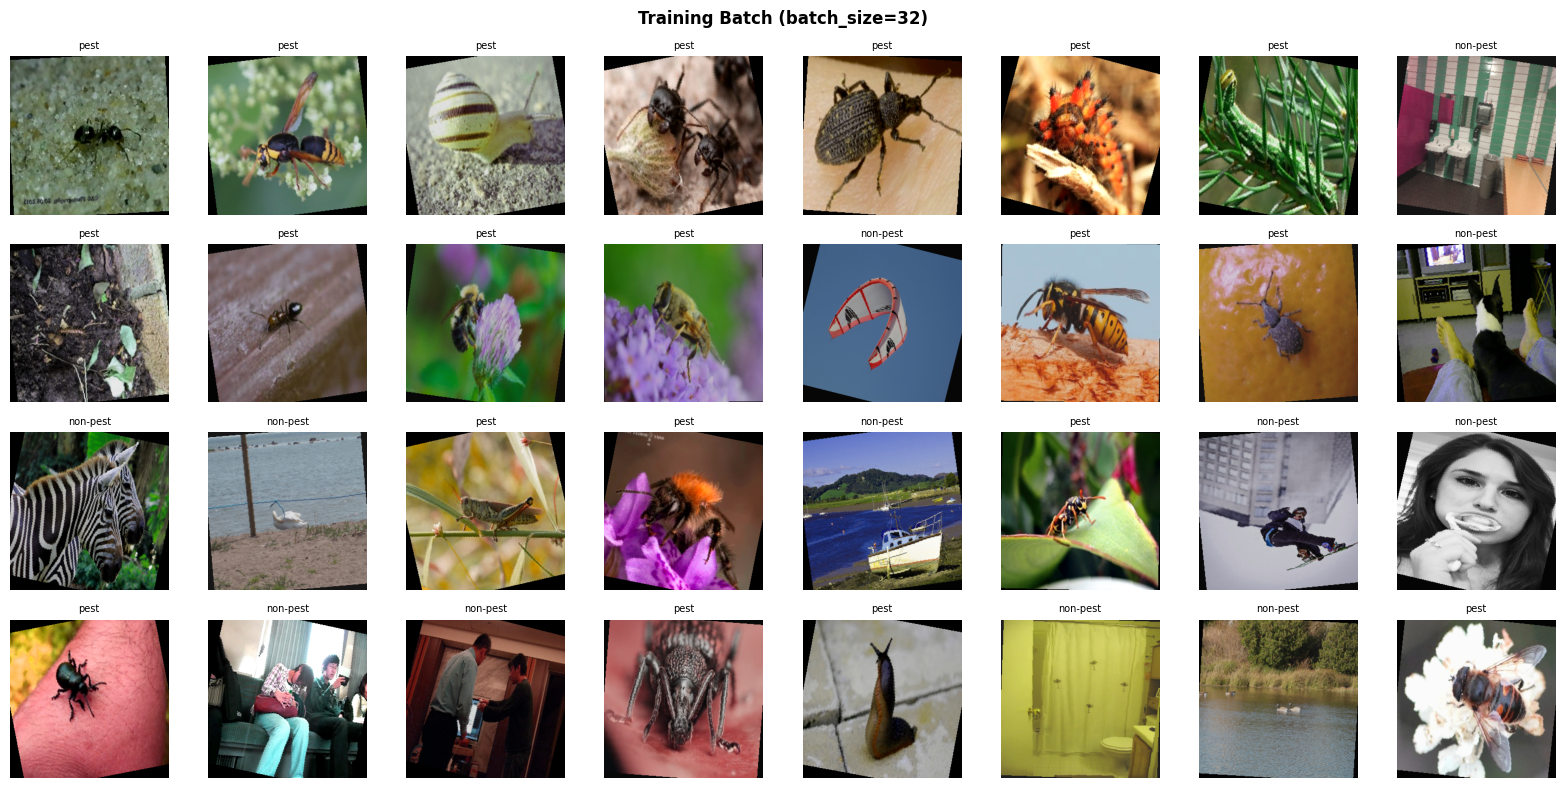

In [10]:
# Check 1 batch
imgs, labels = next(iter(train_loader))
print(f'Batch images shape : {imgs.shape}')   # [B, C, H, W]
print(f'Batch labels shape : {labels.shape}')
print(f'Pixel value range  : [{imgs.min():.3f}, {imgs.max():.3f}]')

# Display 1 batch
def denormalize(tensor, mean=MEAN, std=STD):
    t = tensor.clone()
    for c, m, s in zip(range(3), mean, std):
        t[c] = t[c] * s + m
    return t.clamp(0, 1)

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
axes = axes.flatten()
for i in range(min(32, len(imgs))):
    img_show = denormalize(imgs[i]).permute(1, 2, 0).numpy()
    axes[i].imshow(img_show)
    axes[i].set_title(class_names[labels[i]], fontsize=7)
    axes[i].axis('off')
for j in range(len(imgs), 32):
    axes[j].axis('off')
    
plt.suptitle(f'Training Batch (batch_size={BATCH_SIZE})', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## STEP 4: TRAINING FUNCTIONS & VISUALIZATION

In [11]:
def train_one_epoch(model, loader, criterion, optimizer, device, freeze_bn):
    model.train()
    if freeze_bn:
        set_batchnorm_eval(model)
    running_loss, running_correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad(set_to_none=True)
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        preds = torch.argmax(outputs, dim=1)
        running_loss += loss.item() * images.size(0)
        running_correct += (preds == labels).sum().item()
        total += images.size(0)
    return running_loss / total, running_correct / total

@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss, running_correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        preds = torch.argmax(outputs, dim=1)
        running_loss += loss.item() * images.size(0)
        running_correct += (preds == labels).sum().item()
        total += images.size(0)
    return running_loss / total, running_correct / total

def train_model(model, name, config_lr, epochs_limit, use_freeze_bn=True, early_stop_patience=5):
    device_obj = device
    model = model.to(device_obj)

    head_params = [p for n, p in model.named_parameters() if 'classifier' in n and p.requires_grad]
    backbone_params = [p for n, p in model.named_parameters() if 'classifier' not in n and p.requires_grad]

    param_groups = []
    if backbone_params:
        param_groups.append({'params': backbone_params, 'lr': config_lr['backbone']})
    if head_params:
        param_groups.append({'params': head_params, 'lr': config_lr['head']})
    if not param_groups:
        raise ValueError(f'{name} has no trainable parameters.')

    optimizer = optim.AdamW(param_groups, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device_obj))
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_acc = 0.0
    best_weights = copy.deepcopy(model.state_dict())
    best_val_loss = float('inf')
    es_counter = 0

    print(f"\nStarting training for {name}...")
    for epoch in range(epochs_limit):
        start = time.time()
        t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer, device_obj, use_freeze_bn)
        v_loss, v_acc = validate_one_epoch(model, val_loader, criterion, device_obj)
        scheduler.step(v_loss)

        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)

        elapsed = time.time() - start
        print(f"Epoch {epoch + 1}/{epochs_limit} - Train Loss: {t_loss:.4f}, Acc: {t_acc:.4f} "
              f"| Val Loss: {v_loss:.4f}, Acc: {v_acc:.4f} "
              f"| LR: {optimizer.param_groups[-1]['lr']:.6f} | {elapsed:.1f}s")

        if v_acc > best_acc:
            best_acc = v_acc
            best_weights = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), SAVE_DIR / f'best_{name}.pth')

        if v_loss < best_val_loss:
            best_val_loss = v_loss
            es_counter = 0
        else:
            es_counter += 1
            print(f'  [EarlyStopping] No improvement for {es_counter}/{early_stop_patience} epochs')
            if es_counter >= early_stop_patience:
                print(f'  [EarlyStopping] Stopped at epoch {epoch + 1}!')
                break

    model.load_state_dict(best_weights)
    return model, best_acc, history

def plot_history(history, title='Training History'):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(epochs, history['train_loss'], 'b-o', markersize=3, label='Train Loss')
    ax1.plot(epochs, history['val_loss'], 'r-o', markersize=3, label='Val Loss')
    ax1.set_title(f'{title} - Loss')
    ax1.set_xlabel('Epochs')
    ax1.legend()
    ax1.grid(linestyle='--', alpha=0.5)

    ax2.plot(epochs, [a * 100 for a in history['train_acc']], 'b-o', markersize=3, label='Train Acc')
    ax2.plot(epochs, [a * 100 for a in history['val_acc']], 'r-o', markersize=3, label='Val Acc')
    ax2.set_title(f'{title} - Accuracy')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy (%)')

    if history['val_acc']:
        best_epoch = int(np.argmax(history['val_acc'])) + 1
        ax2.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best epoch={best_epoch}')

    ax2.legend()
    ax2.grid(linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# FUSION MODEL: EFFICIENTNETV2-S + RESNET50
Fusion model extracts features from two pre-trained networks, concatenates them, and passes them through a classifier for binary classification.

In [12]:
# Override DataLoader with smaller batch size to prevent Out Of Memory during Fusion Model training.
BATCH_SIZE_FUSION = 16
print(f'\n[INFO] Re-creating DataLoaders with BATCH_SIZE = {BATCH_SIZE_FUSION} for Fusion Model...')
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE_FUSION, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE_FUSION, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
)
if test_dataset:
    test_loader = DataLoader(
        test_dataset, batch_size=BATCH_SIZE_FUSION, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
    )

class EfficientResNetFusion(nn.Module):
    def __init__(self, num_classes, hidden_dim=512, dropout=0.4, freeze_backbones=True, freeze_bn=True):
        super().__init__()

        eff_net = models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.DEFAULT)
        self.eff_features = eff_net.features
        self.eff_pool = nn.AdaptiveAvgPool2d((1, 1))
        eff_dim = 1280

        resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        self.res_features = nn.Sequential(
            resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool,
            resnet.layer1, resnet.layer2, resnet.layer3, resnet.layer4
        )
        self.res_pool = nn.AdaptiveAvgPool2d((1, 1))
        res_dim = 2048

        if freeze_backbones:
            for p in self.eff_features.parameters():
                p.requires_grad = False
            for p in self.res_features.parameters():
                p.requires_grad = False

        if freeze_bn:
            freeze_batchnorm_layers(self.eff_features)
            freeze_batchnorm_layers(self.res_features)

        self.classifier = nn.Sequential(
            nn.Linear(eff_dim + res_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        feat_e = self.eff_features(x)
        feat_e = torch.flatten(self.eff_pool(feat_e), 1)

        feat_r = self.res_features(x)
        feat_r = torch.flatten(self.res_pool(feat_r), 1)

        fused = torch.cat([feat_e, feat_r], dim=1)
        return self.classifier(fused)

model_fusion = EfficientResNetFusion(NUM_CLASSES, hidden_dim=512, dropout=0.4)

total_fs = sum(p.numel() for p in model_fusion.parameters())
trainable_fs = sum(p.numel() for p in model_fusion.parameters() if p.requires_grad)
print(f'Fusion Model - Total parameters    : {total_fs:,}')
print(f'Fusion Model - Trainable parameters: {trainable_fs:,}')


[INFO] Re-creating DataLoaders with BATCH_SIZE = 16 for Fusion Model...
Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 201MB/s]


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 200MB/s]


Fusion Model - Total parameters    : 45,392,018
Fusion Model - Trainable parameters: 1,706,498


## Train Fusion Model (Frozen Backbones)


========== PHASE 1: TRAINING CLASSIFIER HEAD ==========

Starting training for EfficientNetV2S_ResNet50_Fusion...
Epoch 1/10 - Train Loss: 0.0384, Acc: 0.9869 | Val Loss: 0.0068, Acc: 0.9971 | LR: 0.001000 | 243.5s
Epoch 2/10 - Train Loss: 0.0182, Acc: 0.9945 | Val Loss: 0.0067, Acc: 0.9981 | LR: 0.001000 | 220.5s
Epoch 3/10 - Train Loss: 0.0114, Acc: 0.9969 | Val Loss: 0.0058, Acc: 0.9971 | LR: 0.001000 | 221.3s
Epoch 4/10 - Train Loss: 0.0106, Acc: 0.9961 | Val Loss: 0.0059, Acc: 0.9981 | LR: 0.001000 | 220.5s
  [EarlyStopping] No improvement for 1/5 epochs
Epoch 5/10 - Train Loss: 0.0102, Acc: 0.9957 | Val Loss: 0.0021, Acc: 0.9981 | LR: 0.001000 | 221.3s
Epoch 6/10 - Train Loss: 0.0113, Acc: 0.9958 | Val Loss: 0.0106, Acc: 0.9962 | LR: 0.001000 | 220.7s
  [EarlyStopping] No improvement for 1/5 epochs
Epoch 7/10 - Train Loss: 0.0123, Acc: 0.9967 | Val Loss: 0.0097, Acc: 0.9962 | LR: 0.001000 | 220.6s
  [EarlyStopping] No improvement for 2/5 epochs
Epoch 8/10 - Train Loss: 0.0056, A

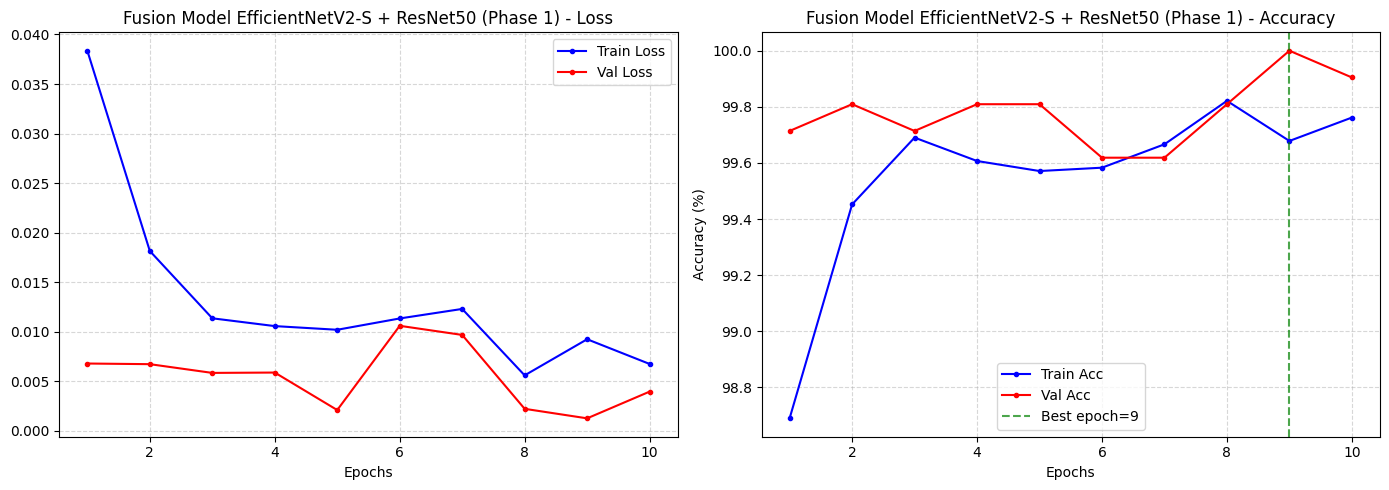

In [13]:
print('\n========== PHASE 1: TRAINING CLASSIFIER HEAD ==========')
lr_config = {'backbone': 1e-4, 'head': LR}

model_fusion, acc_fusion, hist_fusion = train_model(
    model_fusion, 'EfficientNetV2S_ResNet50_Fusion', lr_config, EPOCHS,
    use_freeze_bn=True, early_stop_patience=5
)

plot_history(hist_fusion, title='Fusion Model EfficientNetV2-S + ResNet50 (Phase 1)')

# MODEL PERFORMANCE SUMMARY

In [17]:
print('=' * 60)
print('BEST FUSION MODEL RESULT ON VALIDATION SET:')
print(f'| Phase 1 Val Acc : {acc_fusion * 100:.2f}%')
print('=' * 60)

if test_loader is not None:
    print('\nEvaluating Final Fine-Tuned Model on test set...')
    crit = nn.CrossEntropyLoss(weight=class_weights.to(device))
    _, t_fusion_final = validate_one_epoch(model_fusion, test_loader, crit, device)
    print(f'| Final Test Accuracy: {t_fusion_final * 100:.2f}%')
    print('=' * 60)

BEST FUSION MODEL RESULT ON VALIDATION SET:
| Phase 1 Val Acc : 100.00%

Evaluating Final Fine-Tuned Model on test set...
| Final Test Accuracy: 99.71%


## DETAILED EVALUATION
Visualize Confusion Matrix and report Precision, Recall, F1-Score per class.


Evaluating Precision, Recall, F1 and Confusion Matrix for Fusion Model on TEST SET...



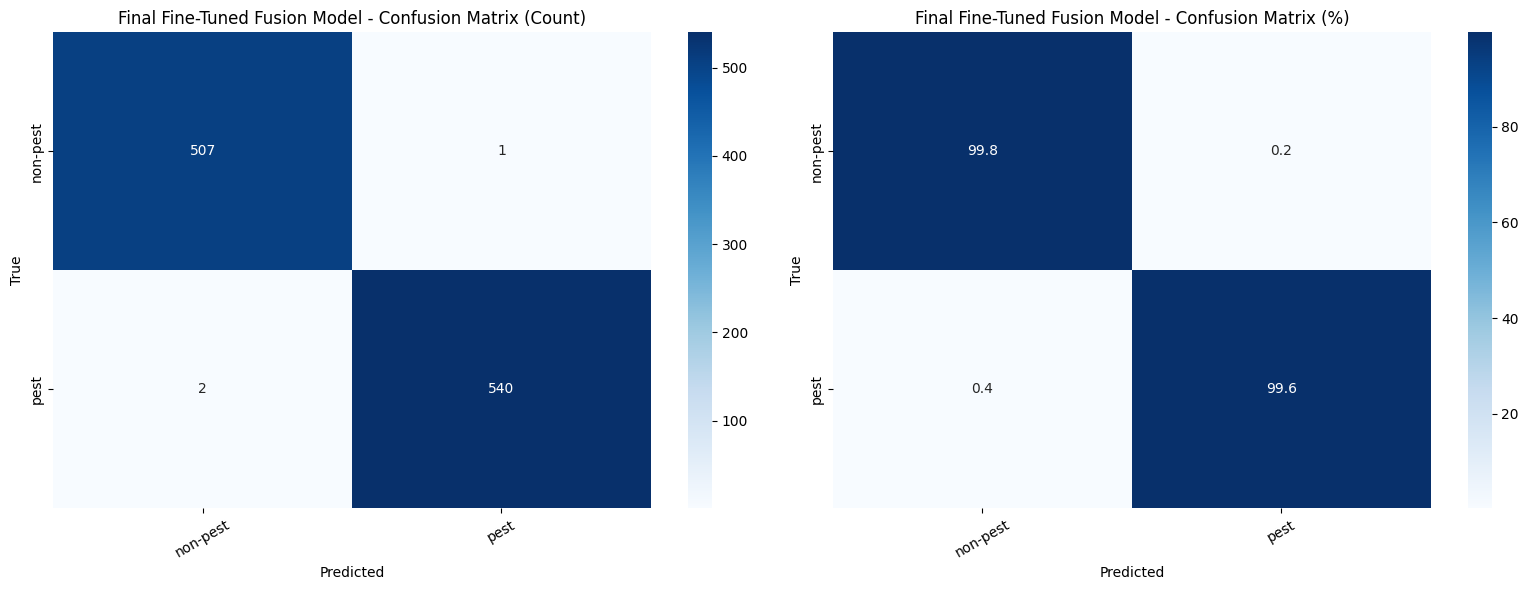


============ CLASSIFICATION REPORT: Final Fine-Tuned Fusion Model ============
              precision    recall  f1-score   support

    non-pest     0.9961    0.9980    0.9971       508
        pest     0.9982    0.9963    0.9972       542

    accuracy                         0.9971      1050
   macro avg     0.9971    0.9972    0.9971      1050
weighted avg     0.9971    0.9971    0.9971      1050





In [18]:
def build_confusion_matrix_np(y_true, y_pred, num_classes):
    cm = np.zeros((num_classes, num_classes), dtype=np.int64)
    for t, p in zip(y_true, y_pred):
        cm[int(t), int(p)] += 1
    return cm

def print_classification_report_np(y_true, y_pred, class_names):
    cm = build_confusion_matrix_np(y_true, y_pred, len(class_names))
    total = cm.sum()
    correct = np.trace(cm)
    print(f'Accuracy: {correct / max(total, 1):.4f}')
    print(f"{'class':<18} {'precision':>10} {'recall':>10} {'f1-score':>10} {'support':>10}")
    for i, name in enumerate(class_names):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        precision = tp / max(tp + fp, 1)
        recall = tp / max(tp + fn, 1)
        f1 = 2 * precision * recall / max(precision + recall, 1e-12)
        support = cm[i, :].sum()
        print(f'{name:<18} {precision:>10.4f} {recall:>10.4f} {f1:>10.4f} {support:>10d}')

def plot_heatmap(ax, matrix, fmt, title, class_names):
    if sns is not None:
        sns.heatmap(matrix, annot=True, fmt=fmt, cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=ax)
    else:
        im = ax.imshow(matrix, cmap='Blues')
        ax.figure.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        ax.set_xticks(np.arange(len(class_names)), labels=class_names)
        ax.set_yticks(np.arange(len(class_names)), labels=class_names)
        for i in range(matrix.shape[0]):
            for j in range(matrix.shape[1]):
                text_value = f'{matrix[i, j]:{fmt}}' if fmt != 'd' else str(int(matrix[i, j]))
                ax.text(j, i, text_value, ha='center', va='center', color='black', fontsize=9)
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=30)
    ax.set_ylabel('True')
    ax.set_xlabel('Predicted')

def plot_confusion_matrix_and_report(model, loader, class_names, title_prefix, device_obj):
    if loader is None:
        print('Dataloader is missing for evaluation.')
        return

    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device_obj)
            outputs = model(imgs)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    labels_range = list(range(len(class_names)))
    if confusion_matrix is not None:
        cm = confusion_matrix(all_labels, all_preds, labels=labels_range)
    else:
        cm = build_confusion_matrix_np(all_labels, all_preds, len(class_names))

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    plot_heatmap(axes[0], cm, 'd', f'{title_prefix} - Confusion Matrix (Count)', class_names)

    cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1) * 100
    plot_heatmap(axes[1], cm_norm, '.1f', f'{title_prefix} - Confusion Matrix (%)', class_names)

    plt.tight_layout()
    plt.show()

    print(f'\n============ CLASSIFICATION REPORT: {title_prefix} ============')
    if classification_report is not None:
        print(classification_report(
            all_labels, all_preds,
            labels=labels_range,
            target_names=class_names,
            digits=4,
            zero_division=0
        ))
    else:
        print_classification_report_np(all_labels, all_preds, class_names)
    print('\n')

eval_loader = test_loader if test_loader is not None else val_loader
eval_name = 'TEST SET' if test_loader is not None else 'VALIDATION SET'
print(f'\nEvaluating Precision, Recall, F1 and Confusion Matrix for Fusion Model on {eval_name}...\n')
plot_confusion_matrix_and_report(model_fusion, eval_loader, class_names, 'Final Fine-Tuned Fusion Model', device)